# Zomato Data Analysis Using Python
Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

- Do more restaurants provide online delivery compared to offline services?
- Which types of restaurants are most favored by the general public?
- What price range do couples prefer for dining out?


In [2]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Creating data frame
dataframe = pd.read_csv("Zomato-data-.csv")

In [4]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [ ]:
# Data cleaning and preparation
def handleRate(value):
    # The code below split our string into two part 4.1 and 5 and then choose the first one of it
    value = str(value).split("/")
    value = value[0]
    return float(value)

dataframe['rate']=dataframe["rate"].apply(handleRate)

In [ ]:
dataframe.head()
#we get rid of the /5 part of the rate

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [ ]:
#Cheking for missing or null values to identify any data gaps
dataframe.isnull().sum() # By looking at the output we can say there is no NULL value in data

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Text(0.5, 0, 'Type of restaurant')

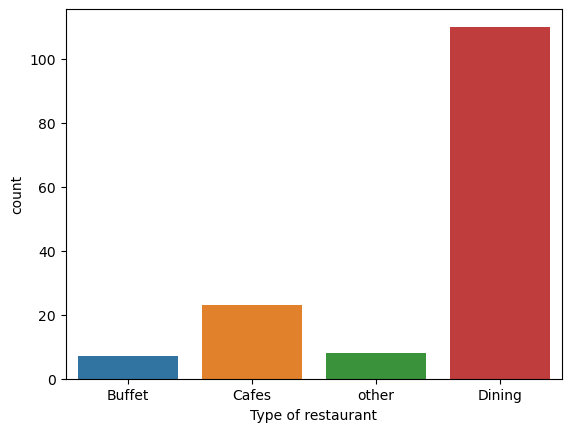

In [ ]:
#Exploring Restaurant Types with plt library
sns.countplot(x=dataframe["listed_in(type)"])
plt.xlabel("Type of restaurant")

Text(0, 0.5, 'Votes')

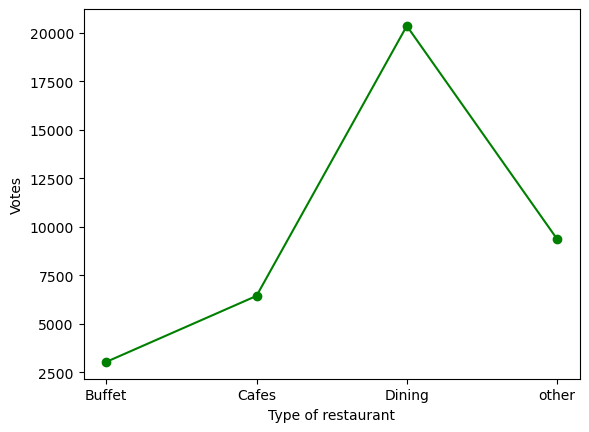

In [25]:
# Votes by Restaurant Type
grouped_data = dataframe.groupby("listed_in(type)")["votes"].sum()
result = pd.DataFrame({"votes": grouped_data})
plt.plot(result, c="green", marker="o")
plt.xlabel("Type of restaurant")
plt.ylabel("Votes")

In [ ]:
max_votes = dataframe["votes"].max()
#With the code below we can find the max value restourant by using pandas
restaurant_with_max_votes = dataframe.loc[dataframe["votes"] == max_votes]
restaurant_with_max_votes

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,Yes,No,4.4,4884,750,other


<Axes: xlabel='online_order', ylabel='count'>

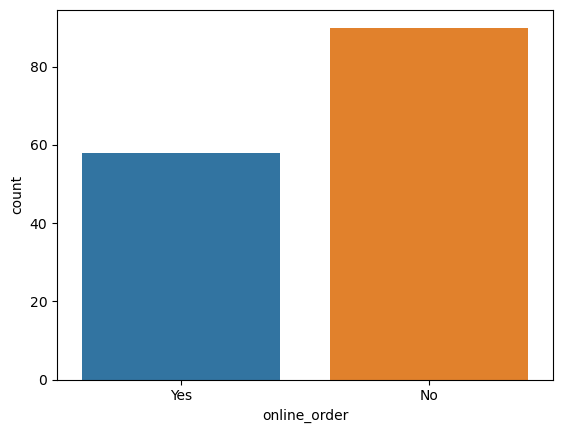

In [35]:
# Onlinde order Availability
sns.countplot(x=dataframe["online_order"])

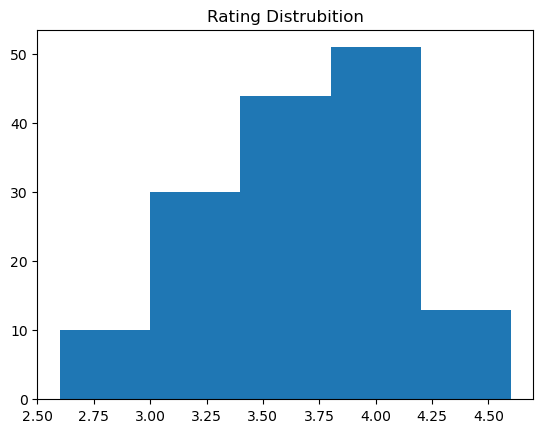

In [55]:
plt.hist(dataframe["rate"], bins=5)
plt.title("Rating Distrubition")
plt.show()

Text(0.5, 0, 'approx cost for two people')

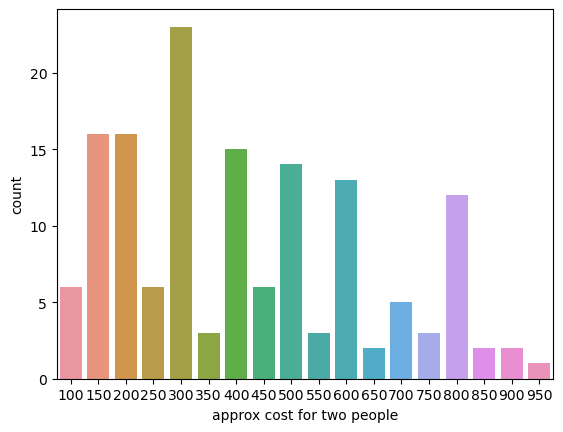

In [63]:
couple_date = dataframe["approx_cost(for two people)"]
sns.countplot(x=couple_date)
plt.xlabel("approx cost for two people")

<Axes: xlabel='online_order', ylabel='rate'>

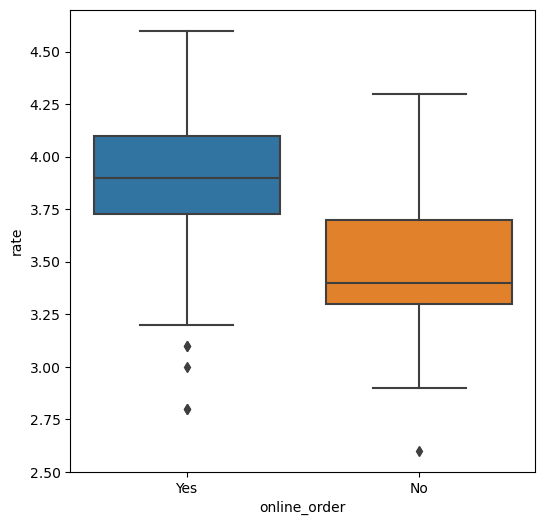

In [64]:
# Rating Comparision - Online vs Offline Orders
plt.figure(figsize=(6,6))
sns.boxplot(x = "online_order", y= "rate", data=dataframe)

In [65]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [66]:
pivot_table = dataframe.pivot_table(index = "listed_in(type)", columns="online_order", aggfunc="size", fill_value=0)


In [68]:
pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


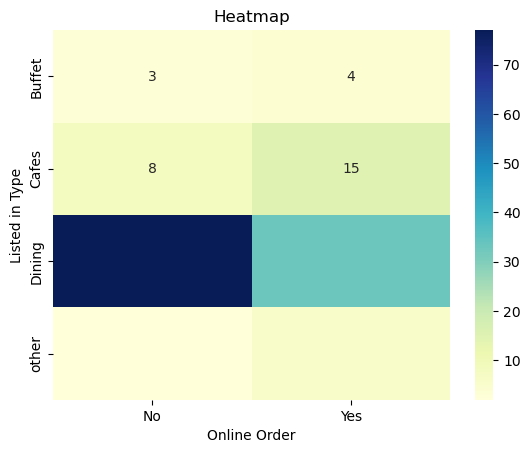

In [70]:
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed in Type")
plt.show()